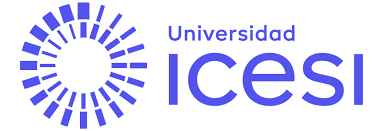

#**<big><big>Matemáticas Aplicadas III</big></big><br><small>Depto. Ciencias Fisicas y Exactas / FIDCA</small><br><small>_*Cuaderno 4*_ (Conjuntos ortogonales en $\mathbf{R}^n$). </small>**

**Lecturas sugeridas**: Secciones 5.3 y 5.4 del libro de Boyd and Vanderberghe(2018).

**<u>Agenda</u>**
* **Conjuntos ortonormales de $\mathbf{R}^n$**
* **Algoritmo de Gram-Schmidt**

---

## **1. Vectores y Conjuntos Ortogonales**

La palabra **ortogonal** es el equivalente geométrico y algebraico de "perpendicular".

### **Definición de Ortogonalidad**
*   **Vectores Ortogonales:** Dos vectores $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ son ortogonales si su producto escalar es igual a cero:
    $$\mathbf{u}^T\mathbf{v} = \mathbf{u} \cdot \mathbf{v} = 0$$
*   **Conjunto Ortogonal:** Una colección de vectores no nulos $T = \{\mathbf{a}_1, \mathbf{a}_2, \dots, \mathbf{a}_k\} \subset \mathbb{R}^n$ es **mutuamente ortogonal** si cada par de vectores distintos tiene un producto punto igual a cero:
    $$\mathbf{a}_i^T\mathbf{a}_j = 0 \quad \text{para todo } i \neq j$$

### **Conjunto Ortonormal**
Un conjunto de vectores $T$ es **ortonormal** si, además de ser mutuamente ortogonales, cada vector es unitario (es decir, su norma o longitud es igual a $1$):
$$\|\mathbf{a}_i\| = 1 \quad \text{para todo } i = 1, \dots, k$$

Podemos resumir estas dos propiedades elegantemente usando la delta de Kronecker ($\delta_{ij}$):
$$\mathbf{a}_i^T \mathbf{a}_j = \begin{cases} 1 & \text{si } i = j \\ 0 & \text{si } i \neq j \end{cases}$$

> 💡 **Nota:** Mientras que la ortogonalidad puede aplicarse a dos vectores individuales, la **ortonormalidad** es un atributo de un conjunto completo de vectores. No tiene sentido decir que "un solo vector es ortonormal".

---

### **Ejemplo de Estudio: Ortogonalización de un Conjunto**
Considere el siguiente conjunto de vectores en $\mathbb{R}^3$:
$$\mathbf{u} = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \quad \mathbf{v} = \begin{bmatrix} 0 \\ 1 \\ -1 \end{bmatrix}, \quad \mathbf{w} = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix}$$

1. **Verificación de Ortogonalidad:** Comprobaremos si los productos mutuos $\mathbf{u}^T\mathbf{v}$, $\mathbf{u}^T\mathbf{w}$ y $\mathbf{v}^T\mathbf{w}$ son nulos.
2. **Construcción del Conjunto Ortonormal:** Dividiremos cada vector por su norma correspondiente para normalizarlos:
   $$\mathbf{q}_i = \frac{\mathbf{a}_i}{\|\mathbf{a}_i\|}$$

In [ ]:
# Verificación y Normalización de un Conjunto Ortogonal
import numpy as np

# Definimos los vectores del ejemplo
u = np.array([1, 0, 0])
v = np.array([0, 1, -1])
w = np.array([0, 1, 1])

# 1. Verificación analítica de ortogonalidad mediante productos puntos
dot_uv = np.dot(u, v)
dot_uw = np.dot(u, w)
dot_vw = np.dot(v, w)

print("--- VERIFICACIÓN DE ORTOGONALIDAD ---")
print(f"u . v = {dot_uv}")
print(f"u . w = {dot_uw}")
print(f"v . w = {dot_vw}")
print(f"¿Son mutuamente ortogonales?: {dot_uv == 0 and dot_uw == 0 and dot_vw == 0}\n")

# 2. Normalización de los vectores para volverlos ortonormales
u_norm = u / np.linalg.norm(u)
v_norm = v / np.linalg.norm(v)
w_norm = w / np.linalg.norm(w)

print("--- CONJUNTO ORTONORMALIZADO ---")
print(f"Vector u normalizado: {u_norm}")
print(f"Vector v normalizado: {v_norm}  (1 / sqrt(2) de [0, 1, -1])")
print(f"Vector w normalizado: {w_norm}  (1 / sqrt(2) de [0, 1,  1])")

---

### **Los vectores ortogonales son Linealmente Independientes**

Es un teorema fundamental que cualquier conjunto de vectores mutuamente ortogonales es **linealmente independiente**.

**¿Cómo demostrarlo usando el producto punto?**
Partamos de la ecuación de dependencia lineal:
$$c_1\mathbf{a}_1 + c_2\mathbf{a}_2 + \dots + c_k\mathbf{a}_k = \mathbf{0}$$

>  Imagina que multiplicas toda esta ecuación por la izquierda usando el vector transpuesto $\mathbf{a}_j^T$ (donde $j$ es cualquier índice elegido entre $1$ y $k$):
> $$\mathbf{a}_j^T (c_1\mathbf{a}_1 + c_2\mathbf{a}_2 + \dots + c_k\mathbf{a}_k) = \mathbf{a}_j^T \mathbf{0}$$
>
> Al distribuir el producto, ¿qué ocurre con términos como $c_1(\mathbf{a}_j^T\mathbf{a}_1)$ si sabemos que el conjunto es mutuamente ortogonal? ¿Cuál es el único término que "sobrevive" del lado izquierdo?

Utiliza la pista anterior para deducir por qué cada uno de los coeficientes $c_j$ debe ser obligatoriamente igual a cero.

---

## **2. Combinación Lineal de Vectores Ortogonales**

Si tenemos un vector $\mathbf{x} \in \mathbb{R}^n$ que se puede escribir como una combinación lineal de un conjunto de vectores mutuamente ortogonales $B = \{\mathbf{a}_1, \mathbf{a}_2, \dots, \mathbf{a}_n\}$:
$$\mathbf{x} = c_1\mathbf{a}_1 + c_2\mathbf{a}_2 + \dots + c_n\mathbf{a}_n \qquad (1)$$

Podemos encontrar de manera inmediata el valor de cada coeficiente individual $c_k$ sin necesidad de realizar eliminación gaussiana (reducción por renglones).

>  Si multiplicamos ambos lados de la ecuación (1) por un vector transpuesto de nuestra base, por ejemplo $\mathbf{a}_k^T$:
> $$\mathbf{a}_k^T \mathbf{x} = c_1(\mathbf{a}_k^T\mathbf{a}_1) + \dots + c_k(\mathbf{a}_k^T\mathbf{a}_k) + \dots + c_n(\mathbf{a}_k^T\mathbf{a}_n)$$
>
> Sabiendo que todos los productos entre vectores diferentes se anulan por ortogonalidad, intenta despejar analíticamente el coeficiente $c_k$.
>
> *Tu despeje debería llevarte a la famosa fórmula de coeficientes de Fourier:*
> $$c_k = \frac{\mathbf{a}_k^T \mathbf{x}}{\|\mathbf{a}_k\|^2}$$

¿Cómo se simplificaría esta fórmula si el conjunto además de ser ortogonal fuese **ortonormal**?

In [ ]:
# Verificación de la obtención rápida de coeficientes
import numpy as np

# Base ortogonal de nuestro primer ejemplo
a1 = np.array([1, 0, 0])
a2 = np.array([0, 1, -1])
a3 = np.array([0, 1, 1])

# Un vector x arbitrario que deseamos descomponer
x = np.array([4, 2, 8])

# Desafío de Código: Completa las fórmulas basadas en tu deducción anterior
# Reemplaza los None por los cálculos de producto punto correctos: np.dot(vector1, vector2)
c1 = np.dot(a1, x) / np.dot(a1, a1)
c2 = np.dot(a2, x) / np.dot(a2, a2)
c3 = np.dot(a3, x) / np.dot(a3, a3)

print("--- COEFICIENTES CALCULADOS DIRECTAMENTE ---")
print(f"c1 = {c1}")
print(f"c2 = {c2}")
print(f"c3 = {c3}")

# Reconstrucción del vector para comprobar consistencia
x_recons = c1*a1 + c2*a2 + c3*a3
print(f"\nVector original x:    {x}")
print(f"Vector reconstruido:  {x_recons}")

---

## **3. Subespacios Ortogonales en $\mathbb{R}^n$ y el "Big Picture"**

No solo los vectores pueden ser ortogonales. Dos subespacios $V$ y $W$ de $\mathbb{R}^n$ se consideran **subespacios ortogonales** si *cada* vector de $V$ es perpendicular a *cada* vector de $W$.

Toda matriz $A \in \mathbb{R}^{m \times n}$ posee cuatro subespacios fundamentales que se agrupan en pares perpendiculares entre sí, como ilustra de forma magistral Gilbert Strang en la siguiente imagen conceptual:

*   **En $\mathbb{R}^n$ (Espacio de Entrada):** El Espacio Fila $C(A^T)$ y el Espacio Nulo $N(A)$ son complementos ortogonales.
*   **En $\mathbb{R}^m$ (Espacio de Salida):** El Espacio Columna $C(A)$ y el Espacio Nulo Izquierdo $N(A^T)$ son complementos ortogonales.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


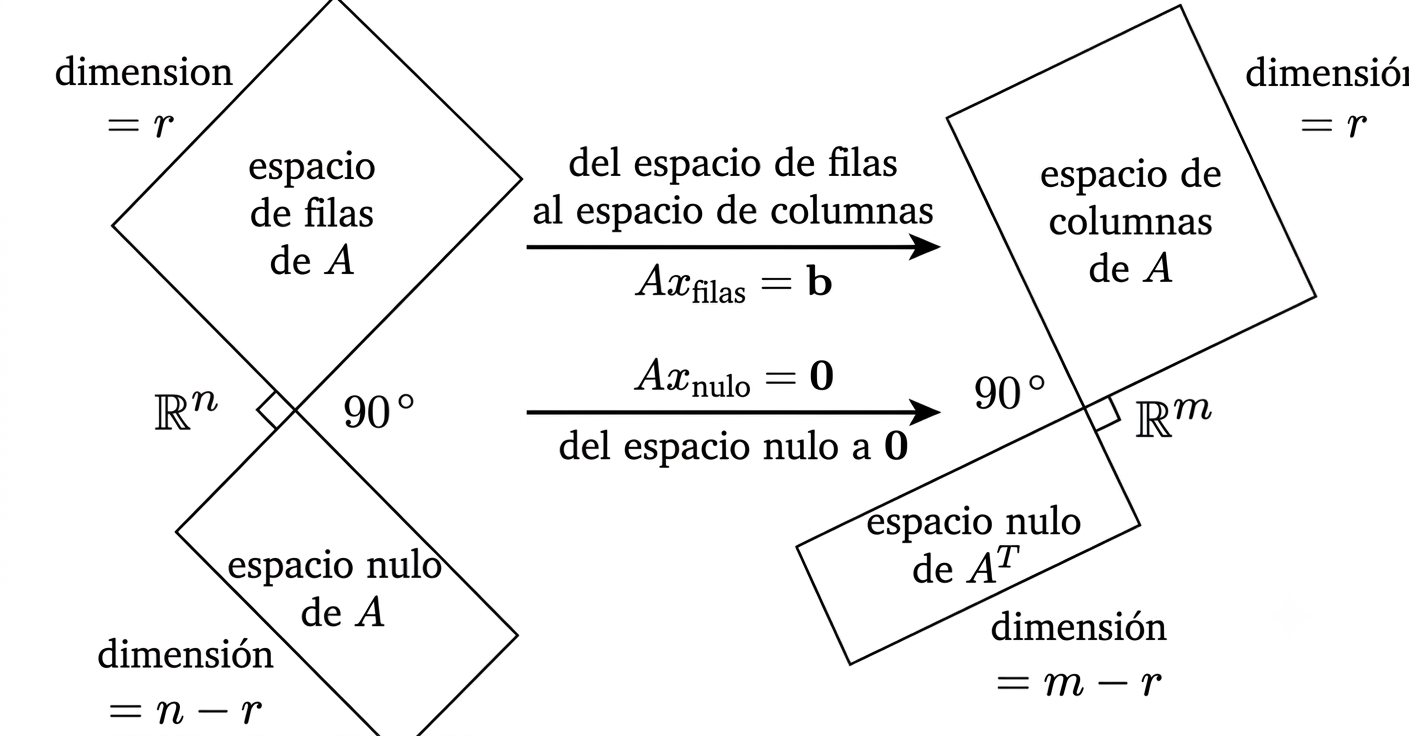

In [4]:
from google.colab import drive
drive.mount('/content/drive')
from IPython.display import Image, display
display(Image(filename="/content/drive/MyDrive/ICESI/Matemáticas_aplicadas_III/Figures/big_picture.png",
              width=650))



### **¿Por qué ocurre esta ortogonalidad?**
Para entender la conexión de la imagen, analicemos la definición del Espacio Nulo $N(A)$:
$$A\mathbf{x} = \mathbf{0} \quad \iff \quad \begin{bmatrix} \text{— } \mathbf{fila}_1 \text{ —} \\ \text{— } \mathbf{fila}_2 \text{ —} \\ \vdots \\ \text{— } \mathbf{fila}_m \text{ —} \end{bmatrix} \mathbf{x} = \begin{bmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}$$

> Nota que la multiplicación de la matriz por el vector es, en esencia, un conjunto de productos puntos individuales entre cada fila de $A$ y el vector $\mathbf{x}$.
> Si $\mathbf{x}$ está en el espacio nulo, su producto escalar con cada fila de la matriz es obligatoriamente cero.
> Dado que el Espacio Fila está constituido por combinaciones lineales de estas filas, ¿qué relación angular mantiene el vector $\mathbf{x}$ con todo el Espacio Fila?

---

## **4. Descomposición por Componentes ($\mathbf{v} = \mathbf{v}_r + \mathbf{v}_n$)**

Note que las dimensiones $r$ del espacio columna de $A$ y $n-r$ del espacio nulo de $A$ suman $n$. El espacio completo de $\mathbb{R}^n$ está determinado de forma que todo vector $\mathbf{v}\in \mathbb{R}^n$ tiene una componente $\mathbf{v}_r$ en el espacio fila de $A$ y una componente $\mathbf{v}_n$ en el espacio nulo de $A$, esto es:
$$\mathbf{v} = \mathbf{v}_r + \mathbf{v}_n$$

Consideremos los espacios fila y nulo de la siguiente matriz:
$$A=\begin{bmatrix} 1 & 2 & 5 \\ 2 & 4 & 10 \\ 3 & 6 & 15 \end{bmatrix}$$

Si le pidieran encontrar los vectores $\mathbf{v}_r$ y $\mathbf{v}_n$ que corresponden al vector $\mathbf{v} = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$, ¿cómo lo haría?

>  **Pista:**
> Recuerde que por medio de combinaciones lineales del generador del espacio fila puede obtener a todos los $\mathbf{v}_r$.

In [ ]:
# Descomposición de v en componente de Espacio Fila (vr) y Espacio Nulo (vn)
import numpy as np

# Definición del vector de entrada y el generador del espacio fila g
v = np.array([1, 1, 1])
g = np.array([1, 2, 5])

# --- COMPLETA LAS FÓRMULAS USANDO LA GUÍA ANTERIOR ---
# Recuerda: np.dot(x, y) calcula el producto punto x^T * y
vr = (np.dot(g, v) / np.dot(g, g)) * g
vn = v - vr

print("--- RESULTADO DE LA DESCOMPOSICIÓN ---")
print(f"Componente vr (Espacio Fila): {vr}")
print(f"Componente vn (Espacio Nulo): {vn}")
print(f"Comprobación Suma vr + vn:    {vr + vn}  (Debe ser [1. 1. 1.])")

# Validación: si vn realmente está en el espacio nulo de A, entonces A * vn debe ser cero.
A = np.array([[1, 2, 5], [2, 4, 10], [3, 6, 15]])
print(f"\nValidación (A * vn): {np.round(np.dot(A, vn), 10)} (Debe ser cercano a [0, 0, 0])")

---

## **5. Algoritmo de Gram-Schmidt**

El algoritmo de Gram-Schmidt permite transformar un conjunto de vectores linealmente independientes en un conjunto de vectores ortonormales que generan exactamente el mismo subespacio.

Para facilitar la intuición y simplificar los cálculos, dividiremos el procedimiento en **dos fases claramente diferenciadas**:

1. **Ortogonalización:** Tomaremos los vectores originales $\mathbf{a}_1, \dots, \mathbf{a}_k$ y les iremos restando sucesivamente sus proyecciones sobre las direcciones ya corregidas. Esto nos entregará un conjunto de vectores mutuamente perpendiculares $\{\tilde{\mathbf{q}}_1, \tilde{\mathbf{q}}_2, \dots, \tilde{\mathbf{q}}_k\}$.
2. **Normalización:** Una vez que todo el conjunto sea ortogonal, simplemente dividiremos cada vector intermedio $\tilde{\mathbf{q}}_i$ por su propia norma para lograr que sean unitarios, obteniendo así la base ortonormal final $\{\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_k\}$.

---

### **1-. Ortogonalización (Resta de Proyecciones)**

*   **i) Definir el primer vector base ($\tilde{\mathbf{q}}_1$)**
    Tomamos el primer vector original tal como está:
    $$\tilde{\mathbf{q}}_1 = \mathbf{a}_1$$

*   **ii) Hacer que el segundo vector sea perpendicular al primero ($\tilde{\mathbf{q}}_2$)**
    Tomamos el vector original $\mathbf{a}_2$ y le **restamos su proyección** sobre la dirección de nuestro primer vector $\tilde{\mathbf{q}}_1$:
    $$\tilde{\mathbf{q}}_2 = \mathbf{a}_2 - \text{proj}_{\tilde{\mathbf{q}}_1}(\mathbf{a}_2) = \mathbf{a}_2 - \left(\frac{\tilde{\mathbf{q}}_1^T \mathbf{a}_2}{\tilde{\mathbf{q}}_1^T \tilde{\mathbf{q}}_1}\right)\tilde{\mathbf{q}}_1$$

*   **iii) Hacer que el tercer vector sea perpendicular a los anteriores ($\tilde{\mathbf{q}}_3$)**
    Tomamos el vector original $\mathbf{a}_3$ y le restamos de manera simultánea sus proyecciones sobre las direcciones ya ortogonalizadas ($\tilde{\mathbf{q}}_1$ y $\tilde{\mathbf{q}}_2$):
    $$\tilde{\mathbf{q}}_3 = \mathbf{a}_3 - \left(\frac{\tilde{\mathbf{q}}_1^T \mathbf{a}_3}{\tilde{\mathbf{q}}_1^T \tilde{\mathbf{q}}_1}\right)\tilde{\mathbf{q}}_1 - \left(\frac{\tilde{\mathbf{q}}_2^T \mathbf{a}_3}{\tilde{\mathbf{q}}_2^T \tilde{\mathbf{q}}_2}\right)\tilde{\mathbf{q}}_2$$

    *   **iv)** De haber mas vectores, el paso 3 debe repetirse con cada $\mathbf{a}_2.$

---

### **2-. Normalización (Volverlos Unitarios)**

Una vez que tenemos el conjunto intermedio de vectores mutuamente ortogonales $\{\tilde{\mathbf{q}}_1, \tilde{\mathbf{q}}_2, \dots, \tilde{\mathbf{q}}_k\}$, el paso final para construir la base ortonormal es escalarlos a magnitud $1$:

$$\mathbf{q}_i = \frac{\tilde{\mathbf{q}}_i}{\|\tilde{\mathbf{q}}_i\|} \quad \text{para cada } i = 1, \dots, k$$

>  Observa detenidamente la ilustración de abajo. Identifica en la tercera fila de discos cómo primero se obtiene la dirección perpendicular $\tilde{\mathbf{q}}_2$ restando la proyección de $\mathbf{a}_2$ sobre $\mathbf{q}_1$. En el último disco de la derecha, se reduce la escala de ese vector hasta tocar el borde del círculo unitario ($\mathbf{q}_2$). ¿Cómo expresarías analíticamente el producto punto $\tilde{\mathbf{q}}_1^T\tilde{\mathbf{q}}_2$ basándote en que ahora son perpendiculares?



---

### **Ejemplo Práctico de Gram-Schmidt**

Considere los siguientes vectores en $\mathbb{R}^4$:
$$\mathbf{a}_1 = \begin{bmatrix} -1 \\ 1 \\ -1 \\ 1 \end{bmatrix}, \quad \mathbf{a}_2 = \begin{bmatrix} -1 \\ 3 \\ -1 \\ 3 \end{bmatrix}, \quad \mathbf{a}_3 = \begin{bmatrix} 1 \\ 3 \\ 5 \\ 7 \end{bmatrix}$$

Utilizaremos el algoritmo implementado en Python para determinar si estos vectores forman un conjunto linealmente independiente y, de ser así, hallar la base ortonormal correspondiente.

In [ ]:
# Implementación de Gram-Schmidt: Primero Ortogonalizar todo, Luego Normalizar todo
import numpy as np

def gram_schmidt_dos_fases(vectores_A):
    """
    Algoritmo de Gram-Schmidt:
    Fase 1: Ortogonaliza todos los vectores quitando proyecciones secuenciales.
    Fase 2: Normaliza el conjunto resultante para devolver una base ortonormal.
    """
    Q_tilde = []  # Lista para acumular los vectores ortogonales intermedios

    # === 1: ORTOGONALIZACIÓN ===
    for idx, a in enumerate(vectores_A):
        q_temp = np.copy(a).astype(float)

        # Restamos las proyecciones sobre los vectores ORTOGONALES acumulados hasta ahora
        for q_ort in Q_tilde:
            # Fórmula de proyección clásica sobre vectores no normalizados:
            # (q_ort^T * a / ||q_ort||^2) * q_ort
            coeficiente = np.dot(q_ort, a) / np.dot(q_ort, q_ort)
            q_temp -= coeficiente * q_ort

        # Detección de dependencia lineal
        if np.linalg.norm(q_temp) < 1e-10:
            print(f"El vector en el índice {idx} es linealmente dependiente.")
            return None

        Q_tilde.append(q_temp)

    print("--- FASE 1 COMPLETADA: Vectores Mutuamente Ortogonales (Q_tilde) ---")
    for i, q_ort in enumerate(Q_tilde):
        print(f"v_tilde_{i+1} = {np.round(q_ort, 4)}")

    # === 2: NORMALIZACIÓN ===
    Q_final = []
    for q_ort in Q_tilde:
        q_normalizado = q_ort / np.linalg.norm(q_ort)
        Q_final.append(q_normalizado)

    return np.array(Q_final).T

# --- PRUEBA CON EL EJEMPLO ---
a1 = np.array([-1, 1, -1, 1])
a2 = np.array([-1, 3, -1, 3])
a3 = np.array([1, 3, 5, 7])

# Ejecución del algoritmo en dos fases
Q_base = gram_schmidt_dos_fases([a1, a2, a3])

if Q_base is not None:
    print("\n--- FASE 2 COMPLETADA: Base Ortonormal Final (Q) ---")
    print(np.round(Q_base, 4))

    # Comprobamos que Q^T * Q sea la matriz identidad (para verificar la ortonormalidad)
    print("\n--- COMPROBACIÓN Q^T * Q (Debería aproximarse a la Identidad) ---")
    print(np.round(np.dot(Q_base.T, Q_base), 10))

---

## **6. Matrices Ortogonales**

Para finalizar, estudiaremos la construcción de matrices utilizando vectores ortonormales. Considere las siguientes matrices:

$$Q_1=\frac{1}{3}\begin{bmatrix} 2 \\ 2 \\ -1 \end{bmatrix}, \quad Q_2=\frac{1}{3}\begin{bmatrix} 2 & 2 \\ 2 & -1 \\ -1 & 2 \end{bmatrix}, \quad Q_3=\frac{1}{3}\begin{bmatrix} 2 & 2 & -1 \\ 2 & -1 & 2 \\ -1 & 2 & 2 \end{bmatrix}$$

Es fácil verificar que $Q_i^T Q_i = I_n$, donde $n$ es el número de columnas de $Q_i$. Cuando una matriz es cuadrada y satisface esta propiedad, decimos que es una **matriz ortogonal** (como el caso de $Q_3$).

### **Matrices de Proyección Ortogonal ($P = Q Q^T$)**
Por otro lado, una matriz $P$ de la forma $P = Q Q^T$ tiene la interesante propiedad de que volver a proyectar un vector ya proyectado no altera el resultado ($P^2 = P$):

$$P^2 = (QQ^T)(QQ^T) = Q(Q^T Q)Q^T = Q(I)Q^T = QQ^T = P$$

La ecuación $P^2 = P$ nos dice que $P$ es una **matriz de proyección**. Más aún, si $P^2 = P = P^T$, entonces el producto $P\mathbf{b}$ representa la proyección ortogonal del vector $\mathbf{b}$ sobre el espacio columna de $P$.

---

### **Ejemplo de Proyección**

Considere el vector $\mathbf{b} = \begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix}$ que claramente no pertenece a la recta $\ell$ generada por $Q_1$, ni al plano $\pi$ generado por las columnas de $Q_2$. Sus proyecciones están dadas por:

**Proyección sobre la recta $\ell$:**

$$P_1\mathbf{b} = \frac{1}{9}\begin{bmatrix} 2 \\ 2 \\ -1 \end{bmatrix} \begin{bmatrix} 2 & 2 & -1 \end{bmatrix} \begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix} = \begin{bmatrix} 2 \\ 2 \\ -1 \end{bmatrix}$$

**Proyección sobre el plano $\pi$:**

$$P_2\mathbf{b} = \frac{1}{9}\begin{bmatrix} 2 & 2 \\ 2 & -1 \\ -1 & 2 \end{bmatrix} \begin{bmatrix} 2 & 2 & -1 \\ 2 & -1 & 2 \end{bmatrix} \begin{bmatrix} 3 \\ 3 \\ 3 \end{bmatrix} = \begin{bmatrix} 4 \\ 1 \\ 1 \end{bmatrix}$$
> **¿Qué efecto tiene la matriz $P_3 = Q_3 Q_3^T$ sobre el vector $\mathbf{b}$? ¿Por qué crees que ocurre este fenómeno geométrico al usar todas las columnas de una base completa de $\mathbb{R}^3$?**

In [ ]:
# Verificación numérica de proyecciones y matrices ortogonales
import numpy as np

# Definimos las matrices Q_i
Q1 = (1/3) * np.array([[2], [2], [-1]])
Q2 = (1/3) * np.array([[2, 2], [2, -1], [-1, 2]])
Q3 = (1/3) * np.array([[2, 2, -1], [2, -1, 2], [-1, 2, 2]])

b = np.array([3, 3, 3])

# Ejercicio de Código: Construye las matrices de proyección P1, P2 y P3 usando la fórmula P = Q * Q^T
# Pista: En NumPy, la transpuesta de un vector o matriz X se calcula con X.T
P1 = np.dot(Q1, Q1.T)
P2 = np.dot(Q2, Q2.T)
P3 = np.dot(Q3, Q3.T)

print("--- PROYECCIÓN P1 * b (Sobre la Recta) ---")
print(np.dot(P1, b))

print("\n--- PROYECCIÓN P2 * b (Sobre el Plano) ---")
print(np.dot(P2, b))

print("\n--- PROYECCIÓN P3 * b (Sobre el espacio R^3 completo) ---")
print(np.dot(P3, b))

In [1]:
#@title Visualizador Interactivo de la Proyección en GeoGebra { display-mode: "form" }
# Utiliza esta herramienta para observar cómo el vector b es proyectado ortogonalmente sobre planos y rectas.
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/svupghzp",
  width="100%",
  height="480px"
  )

IP.display_html(iframe)